# Function 1

<b> Description of the Sample Application:</b> Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 06/08/2026 | Week 3 | 1. Consolidated Week 1 (UCB) and Week 2 (EI) logic into a single reusable bayesian_optimization_2d_step function.<br>2. Reduced exploration floor (xi_multiplier: 3.0 to 2.0, 80:20 to 70:30). |
| 13/08/2026 | Week 4 | 1. Input and output data points from Week 3 appended.<br>2. Reduced exploration floor (xi_multiplier: 2.0 to 1.5, 70:30 to 60:40). ||


# Weekly Progress Log

| Week | Method | Exploration:Exploitation | Query (x1, x2) | Output (y) | Best-so-far |
|---|---|---|---|---|---|
| Initial | Provided data (10 points) | - | - | - | 7.710875e-16 |
| 1 | GP-UCB (β=2.5), space-filling exploration | 90:10 | (0.617450, 0.872483) | -4.579196e-42 | 7.710875e-16 |
| 2 | GP-Expected Improvement (EI), exploration floor via scaled xi (xi_multiplier=3.0) | 80:20 | (0.785234, 0.798657) | 1.170424e-37 | 7.710875e-16 || 3 | GP-Expected Improvement (EI), reduced exploration floor (xi_multiplier=2.0) | 70:30 | (0.818791, 0.711409) | -5.679812e-31 | 7.710875e-16 |
| 4 | GP-Expected Improvement (EI), further reduced exploration floor (xi_multiplier=1.5) | 60:40| - | - | - ||||

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import norm
from plotting_utils import plot_2d_bo_state, plot_convergence

# Load and Analyse the Data

In [113]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X              = np.load(input_file)
Y              = np.load(output_file)

In [115]:
# New data from Week 1 submission
X_w1_new_point = np.array([0.644295, 0.872483]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-4.57919574117409e-42], dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.785234, 0.798657]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([1.1704238583798859e-37], dtype=np.float64)   # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.818791, 0.711409]    , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([-5.679811964041589e-31], dtype=np.float64)   # from output.txt

In [117]:
# Append the new data points
X_updated      = np.vstack((X, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                           ))
Y_updated      = np.append(Y, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                              ])


In [119]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.644295   0.872483  ]
 [0.785234   0.798657  ]
 [0.818791   0.711409  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -4.57919574e-042  1.17042386e-037
 -5.67981196e-031]


In [121]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()
print("Minimum and Maximum Values of Output:\n")
print("Min:", Y.min(), " Max:", Y.max())
print("Best point:", X[np.argmax(Y)], "-> Output =", Y.max())
print()

# Converting the Input and Output into a DataFram
df           = pd.DataFrame(X, columns = [f'Input_{i+1}' for i in range(X.shape[1])])
df['Output'] = Y
print("Data Frame:\n", df)

Input  Shape: (13, 2)
Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.644295   0.872483  ]
 [0.785234   0.798657  ]
 [0.818791   0.711409  ]]

Output Shape: (13,)
Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -4.57919574e-042  1.17042386e-037
 -5.67981196e-031]

Minimum and Maximum Values of Output:

Min: -0.0036060626443634764  Max: 7.710875114502849e-16
Best point: [0.73102363 0.73299988] -> Output = 7.710875114502849e-16

Data Frame:
      Input_1   Input_2         Output
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.

# Data Exploration

In [124]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
          Input_1    Input_2        Output
count  13.000000  13.000000  1.300000e+01
mean    0.595114   0.598288 -2.773894e-04
std     0.244013   0.281550  1.000142e-03
min     0.082507   0.078723 -3.606063e-03
25%     0.410437   0.403488 -2.159249e-54
50%     0.650114   0.711409  3.606771e-81
75%     0.785234   0.798657  1.033078e-46
max     0.883890   0.879898  7.710875e-16


In [126]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 Input_1    0
Input_2    0
Output     0
dtype: int64


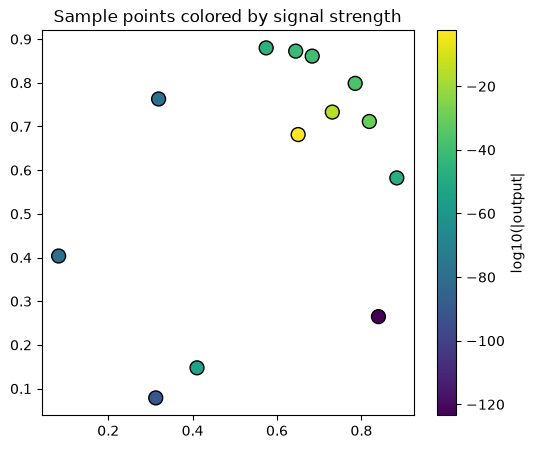

In [128]:
# Scatter Plot
magnitude = np.log10(np.abs(Y) + 1e-300)
fig, ax   = plt.subplots(figsize = (6,5))
sc        = ax.scatter(X[:,0], X[:,1], c = magnitude, cmap = 'viridis', s = 100, edgecolor = 'black')
plt.colorbar(sc, label = 'log10(|output|')
ax.set_title('Sample points colored by signal strength')
plt.show()

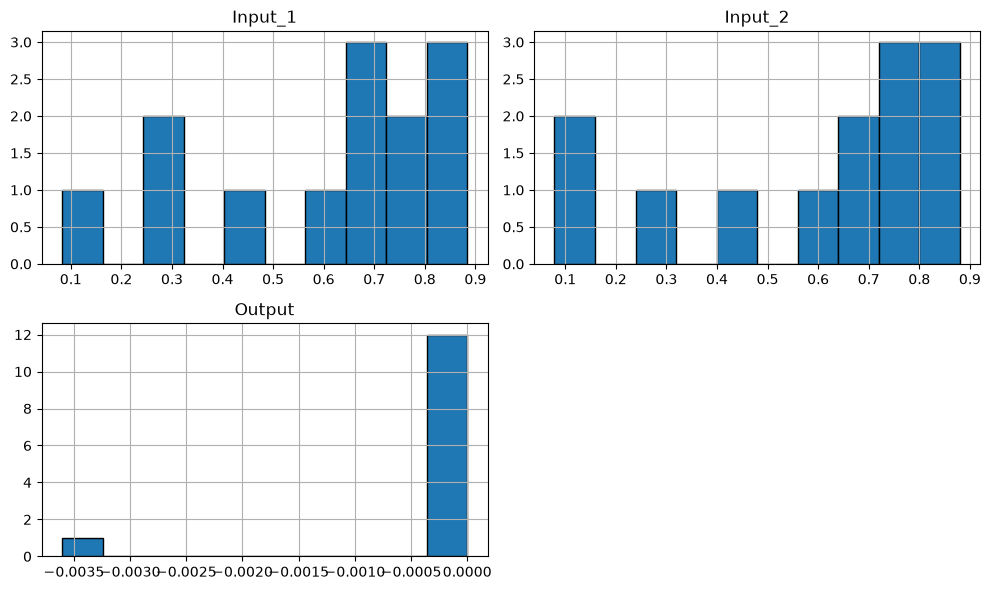

In [130]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'black' )
plt.tight_layout()
plt.show()

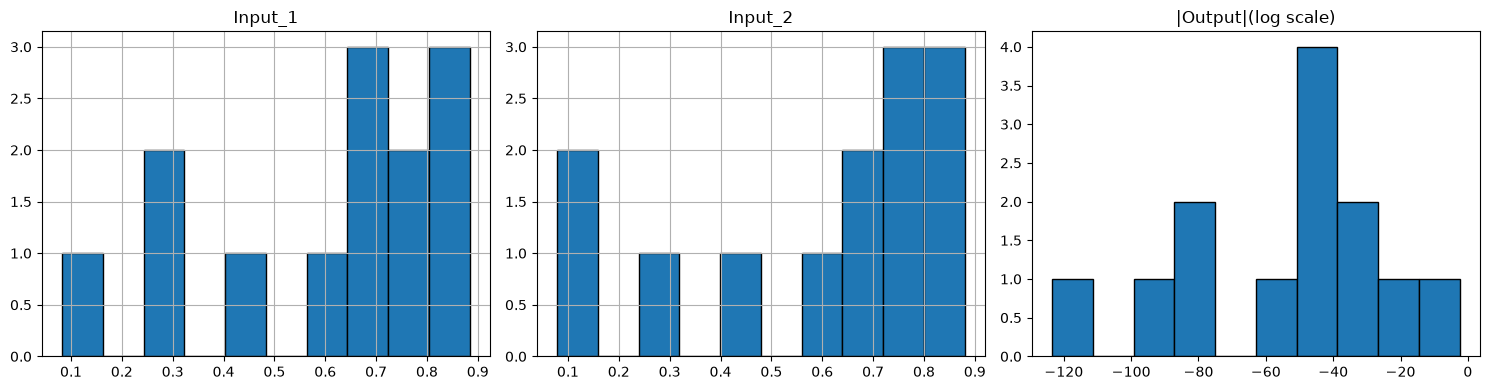

In [132]:
# In the above histogram for the output column, almost every bar seems to be crammed into a single bin near zero, which is not very informative.
# Plotting the column histograms using log scale for Output column
fig, axes = plt.subplots(1,3, figsize = (15,4))

df['Input_1'].hist(ax = axes[0], bins = 10, edgecolor = 'black')
axes[0].set_title('Input_1')

df['Input_2'].hist(ax = axes[1], bins = 10, edgecolor = 'black')
axes[1].set_title('Input_2')

magnitude = np.where(Y != 0, np.log10(np.abs(Y) + 1e-300), np.nan)
axes[2].hist(magnitude, bins = 10, edgecolor = 'black')
axes[2].set_title('|Output|(log scale)')


plt.tight_layout()
plt.show()

# Nearest-Pair Check

In [135]:
D      = squareform(pdist(X))
i, j   = np.unravel_index(np.argmin(D + np.eye(len(X))*99), D.shape)
print(f"Closest pair: idx {i} & {j}, distance={D[i,j]:.4f}, y_i={Y[i]:.3e}, y_j={Y[j]:.3e}")

Closest pair: idx 7 & 10, distance=0.0408, y_i=2.535e-40, y_j=-4.579e-42


# Initialize Gaussian Process

In [138]:
#Define the kernel and initialise the GP model

# Week 1 ( Using RBF GP Surrogate )
kernel_rbf   = ConstantKernel(1.0) * RBF(length_scale = 0.2, length_scale_bounds = (0.02, 1.0)) \
                + WhiteKernel(noise_level = 1e-6, noise_level_bounds = (1e-10, 1e-2))
gpr          = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [141]:
# Train the model

# Week 1 fit to RBF GP Surrugate
gpr.fit(X, Y)
print("Learned kernel (Week 1): ", gpr.kernel_)

Learned kernel (Week 1):  1.02**2 * RBF(length_scale=0.0531) + WhiteKernel(noise_level=1.58e-10)


# Week 1: Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [145]:
grid_res   = 150
xs         = np.linspace(0, 1, grid_res)
ys         = np.linspace(0, 1, grid_res)
gx, gy     = np.meshgrid(xs, ys)
candidates = np.column_stack([gx.ravel(), gy.ravel()])

mu, std    = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta       = 2.5
ucb        = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.30872483 0.18791946]
Predicted Mean(μ): -2.155153e-04
Predicted Std (σ): 9.697328e-04
UCB Score: 2.208817e-03


# Perform Visualisation ( Week 1 )

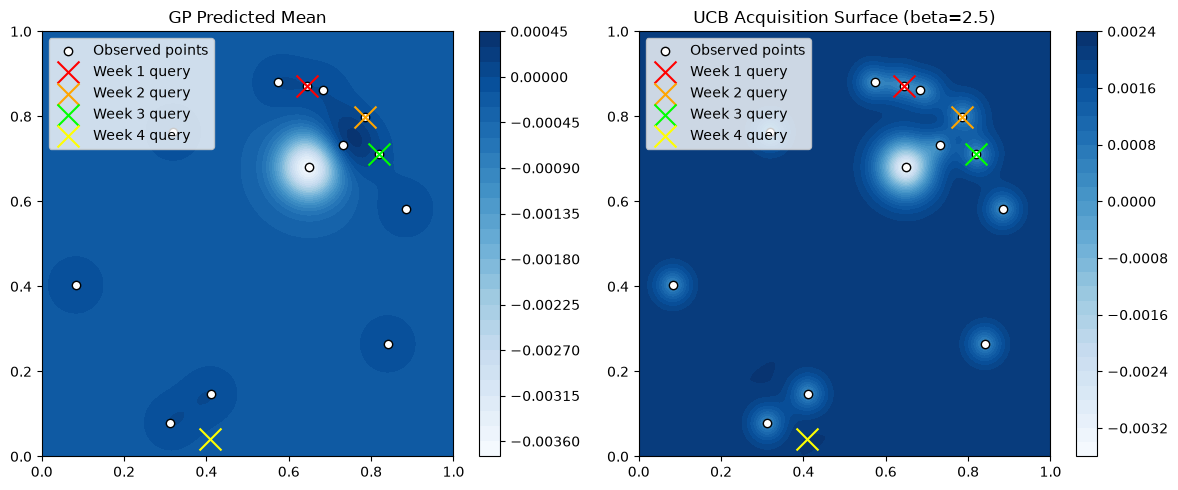

In [176]:
fig, axes  = plt.subplots(1,2, figsize = (12, 5))

# Predicted mean surface
c0 = axes[0].contourf(gx, gy, mu.reshape(gx.shape), levels=30, cmap="Blues")
axes[0].scatter(X[:, 0], X[:, 1] , c = "white" , edgecolor = "black", label = "Observed points")
axes[0].scatter(*X_w1_new_point  , c = "red"   , marker    = "x"    , s=250, label = "Week 1 query")
axes[0].scatter(*X_w2_new_point  , c = "orange", marker    = "x"    , s=250, label = "Week 2 query")
axes[0].scatter(*X_w3_new_point  , c = "lime"  , marker    = "x"    , s=250, label = "Week 3 query")
axes[0].scatter(*next_point_w4   , c = "yellow" , marker   = "x"    , s=250, label = "Week 4 query")

axes[0].set_title("GP Predicted Mean")
axes[0].legend(loc='upper left')
fig.colorbar(c0, ax=axes[0])

# UCB acquisition surface
c1 = axes[1].contourf(gx, gy, ucb.reshape(gx.shape), levels=30, cmap="Blues")
axes[1].scatter(X[:, 0], X[:, 1] , c = "white" , edgecolor = "black", label = "Observed points")
axes[1].scatter(*X_w1_new_point  , c = "red"   , marker    = "x"    , s     = 250, label = "Week 1 query")
axes[1].scatter(*X_w2_new_point  , c = "orange", marker    = "x"    , s     = 250, label = "Week 2 query")
axes[1].scatter(*X_w3_new_point  , c = "lime"  , marker    = "x"    , s     = 250, label = "Week 3 query")
axes[1].scatter(*next_point_w4   , c = "yellow"  , marker    = "x"    , s     = 250, label = "Week 4 query")

axes[1].set_title("UCB Acquisition Surface (beta=2.5)")
axes[1].legend(loc='upper left')
fig.colorbar(c1, ax=axes[1])

plt.tight_layout()
plt.show()

# Week 2: Compute the EI acquisition Function

In [89]:
grid_res = 150

# Define Expected Improvement Acquisition Function
def expected_improvement(mu, sigma, y_best, xi):
    """EI = E[max(f(x) - f(x_best), 0)]"""
    sigma   = np.maximum(sigma, 1e-9)
    z       = (mu - y_best - xi) / sigma
    ei      = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-9] = 0.0
    return ei

# Define Bayesian Optimisation Function for Week2
def bayesian_optimization_2d_step(X_samples, y_samples, bounds, xi_multiplier = 3.0, grid_res = grid_res, nu = 2.5):
    """
    Single-step 2D Bayesian Optimization, fit a Matern GP, evaluate EI over a dense candidate grid, and return the next query point.
    """

    # Using Matern GP Surrogate
    kernel_matern = ConstantKernel(1.0) * Matern(length_scale = 0.2, length_scale_bounds = (0.02, 1.0), nu = nu) \
                        + WhiteKernel(noise_level = 1e-6, noise_level_bounds = (1e-10, 1e-2))
    
    grp_matern    = GaussianProcessRegressor(kernel = kernel_matern, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

    grp_matern.fit(X_samples, y_samples)
    
    #print("Learned kernel (Week 2): ", grp_matern.kernel_)
    
    # Grid sampling: build a candidate grid over the bounds
    axes         = [np.linspace(b[0], b[1], grid_res) for b in bounds]
    mesh         = np.meshgrid(*axes)
    candidates   = np.column_stack([m.ravel() for m in mesh])

    mu, sigma    = grp_matern.predict(candidates, return_std = True)
    
    xi           = xi_multiplier * y_samples.std()
    ei           = expected_improvement(mu, sigma, y_samples.max(), xi=xi)

    best_idx     = np.argmax(ei)
    X_next       = candidates[best_idx]

    return {
        'gp': grp_matern, 'mesh': mesh, 'candidates': candidates,
        'mu': mu, 'sigma': sigma, 'ei': ei, 'xi': xi,
        'X_next': X_next, 'ei_at_next': ei[best_idx],
        'mu_at_next': mu[best_idx], 'sigma_at_next': sigma[best_idx],
    }
    

result           = bayesian_optimization_2d_step(X, Y, bounds = [(0, 0.999999), (0, 0.999999)], xi_multiplier = 3.0 )

next_point       = result['X_next']

print("Learned kernel          :", result['gp'].kernel_)
print(f"Exploration floor (xi) : {result['xi']:.6e}")
print(f"\nNext query point (EI): {next_point}")
print(f"EI value at next point : {result['ei_at_next']:.6e}")
print(f"Predicted mean (mu)    : {result['mu_at_next']:.6e}")
print(f"Predicted std (sigma)  : {result['sigma_at_next']:.6e}")

Learned kernel          : 1.02**2 * Matern(length_scale=0.0512, nu=2.5) + WhiteKernel(noise_level=3.7e-10)
Exploration floor (xi) : 2.882716e-03

Next query point (EI): [0.42281837 0.02684561]
EI value at next point : 1.735184e-07
Predicted mean (mu)    : -2.376808e-04
Predicted std (sigma)  : 9.720893e-04


# Week 2 Visualisation

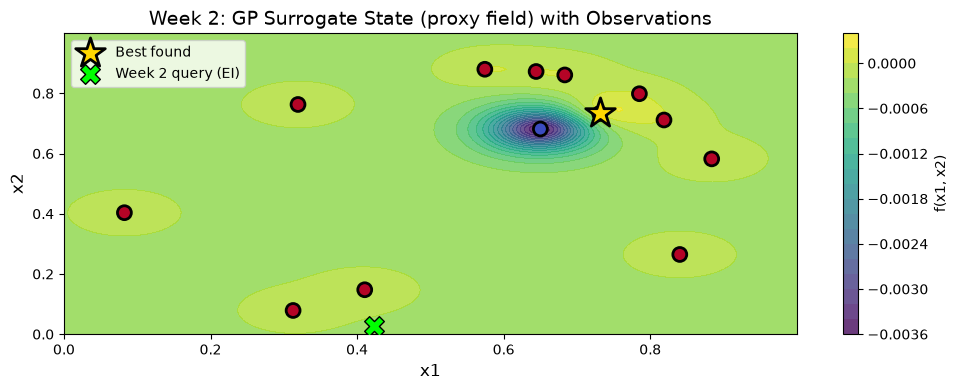

In [92]:
gx, gy   = result['mesh']
Z        = result['mu'].reshape(gx.shape)

fig, ax  = plot_2d_bo_state( gx, gy, Z, X, Y, title = "Week 2: GP Surrogate State (proxy field) with Observations")
ax.scatter(*next_point, marker = 'X', s = 200, c = 'lime', edgecolor = 'black', label = 'Week 2 query (EI)', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Week 3: Consolidated Bayesian Optimization Function

In [95]:
# Define UCB Acquisition Function
def upper_confidence_bound(mu, sigma, beta=2.0):
    """UCB = mean + beta * std"""
    return mu + beta * sigma

# Define Expected Improvement Acquisition Function
def expected_improvement(mu, sigma, y_best, xi):
    """EI = E[max(f(x) - f(x_best), 0)]"""
    sigma   = np.maximum(sigma, 1e-9)
    z       = (mu - y_best - xi) / sigma
    ei      = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-9] = 0.0
    return ei

# Week 3: Consolidated Bayesian Optimization Function
def bayesian_optimization_2d_step(X_samples, y_samples, bounds, acquisition = 'ei',
                                   xi_multiplier = 2.0, beta = 2.0, grid_res = 150, nu = 2.5,
                                   plot = True, week_label = 'Week'):

    kernel_matern = ConstantKernel(1.0) * Matern(length_scale = 0.2, length_scale_bounds =( 0.02, 1.0), nu = nu) \
                        + WhiteKernel(noise_level = 1e-6, noise_level_bounds = (1e-10, 1e-2))

    grp_matern   = GaussianProcessRegressor(kernel = kernel_matern, normalize_y = True,
                                            n_restarts_optimizer = 10, random_state = 0)
    grp_matern.fit(X_samples, y_samples)

    # Grid sampling: build a candidate grid over the bounds
    axes         = [np.linspace(b[0], b[1], grid_res) for b in bounds]
    mesh         = np.meshgrid(*axes)
    candidates   = np.column_stack([m.ravel() for m in mesh])

    mu, sigma    = grp_matern.predict(candidates, return_std = True)

    if acquisition == 'ei':
        xi       = xi_multiplier * y_samples.std()
        acq_vals = expected_improvement(mu, sigma, y_samples.max(), xi=xi)
    else:
        xi       = None
        acq_vals = upper_confidence_bound(mu, sigma, beta = beta)

    best_idx     = np.argmax(acq_vals)
    X_next       = candidates[best_idx]

    print(f"--- {week_label}: Bayesian Optimization ---")
    print(f"Learned kernel        : {grp_matern.kernel_}")
    if xi is not None:
        print(f"Acquisition           : EI (xi = {xi:.6e})")
    else:
        print(f"Acquisition           : UCB (beta = {beta})")
    print(f"Next query point      : {X_next}")
    print(f"Acquisition value     : {acq_vals[best_idx]:.6e}")
    print(f"Predicted mean (mu)   : {mu[best_idx]:.6e}")
    print(f"Predicted std (sigma) : {sigma[best_idx]:.6e}")
    print(f"Best value so far     : {y_samples.max():.6e} at {X_samples[np.argmax(y_samples)]}")

    if plot:
        gx, gy    = mesh
        Z         = mu.reshape(gx.shape)
        fig, ax   = plot_2d_bo_state(gx, gy, Z, X_samples, y_samples,
                                     title = f"{week_label}: GP Surrogate State")
        ax.scatter(*X_next, marker = 'X', s = 200, c = 'lime', edgecolor = 'black',
                   label = f'{week_label} query ({acquisition.upper()})', zorder = 12)
        ax.legend(loc = 'upper left')
        plt.show()

    return {
        'gp': grp_matern, 'mesh': mesh, 'candidates': candidates,
        'mu': mu, 'sigma': sigma, 'acq_vals': acq_vals, 'xi': xi,
        'X_next': X_next, 'acq_at_next': acq_vals[best_idx],
        'mu_at_next': mu[best_idx], 'sigma_at_next': sigma[best_idx],
        'best_so_far': y_samples.max(),
    }


--- Week 3: Bayesian Optimization ---
Learned kernel        : 1.02**2 * Matern(length_scale=0.0512, nu=2.5) + WhiteKernel(noise_level=3.7e-10)
Acquisition           : EI (xi = 1.921810e-03)
Next query point      : [0.30872452 0.18791928]
Acquisition value     : 4.499810e-06
Predicted mean (mu)   : -2.197184e-04
Predicted std (sigma) : 9.660337e-04
Best value so far     : 7.710875e-16 at [0.73102363 0.73299988]


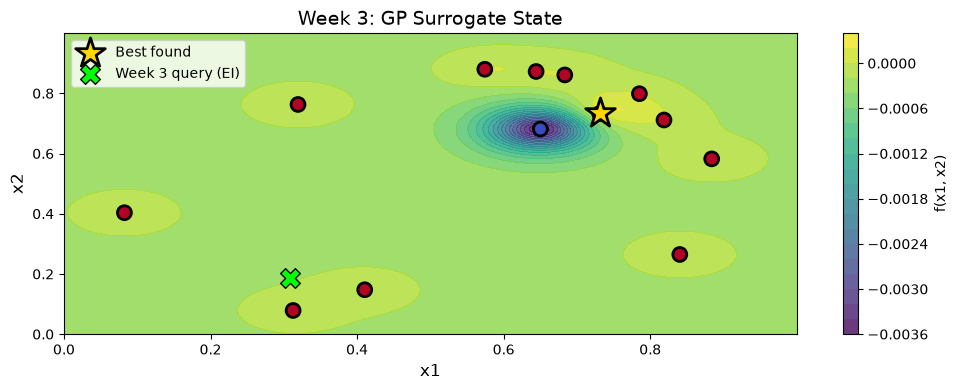

In [97]:
# Run the consolidated function for Week 3
# xi_multiplier reduced from 3.0 (Week 2) to 2.0 -- ~70:30 exploration:exploitation
# Uses the 12-point dataset (X, Y) updated above (Week 1 + Week 2 feedback appended)
result_w3        = bayesian_optimization_2d_step(
    X, Y, bounds = [(0, 0.999999), (0, 0.999999)],
    acquisition  = 'ei', xi_multiplier = 2.0, week_label = 'Week 3'
)

next_point_w3 = result_w3['X_next']

# Week 4: Calling the consolidated Bayesian Optimisation Function
Calling the consolidated function with xi_multiplier reduced from 2.0 (Week 3) to 1.5 to facilitate 60:40 exploration:exploitation

--- Week 4: Bayesian Optimization ---
Learned kernel        : 1.02**2 * Matern(length_scale=0.0512, nu=2.5) + WhiteKernel(noise_level=3.7e-10)
Acquisition           : EI (xi = 1.441358e-03)
Next query point      : [0.40939556 0.04026842]
Acquisition value     : 1.686810e-05
Predicted mean (mu)   : -2.129990e-04
Predicted std (sigma) : 9.631274e-04
Best value so far     : 7.710875e-16 at [0.73102363 0.73299988]


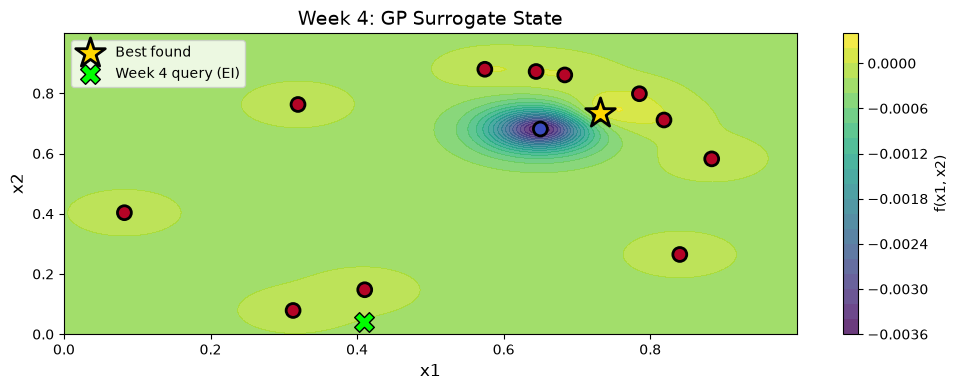

In [162]:
result_w4        = bayesian_optimization_2d_step(
    X, Y, bounds = [(0, 0.999999), (0, 0.999999)],
    acquisition  = 'ei', xi_multiplier = 1.5, week_label = 'Week 4'
)

next_point_w4 = result_w4['X_next']

# Portal Submission 

In [167]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point_w4[0]:.6f}-{next_point_w4[1]:.6f}"
print("Points to be submitted (Week 1):", '0.644295-0.872483')
print("Points to be submitted (Week 2):", '0.785234-0.798657')
print("Points to be submitted (Week 3):", '0.818791-0.711409')
print("Points to be submitted (Week 4):", submission_str)
print()

Points to be submitted (Week 1): 0.644295-0.872483
Points to be submitted (Week 2): 0.785234-0.798657
Points to be submitted (Week 3): 0.818791-0.711409
Points to be submitted (Week 4): 0.409396-0.040268



# Plot the Progress of the optimisation process

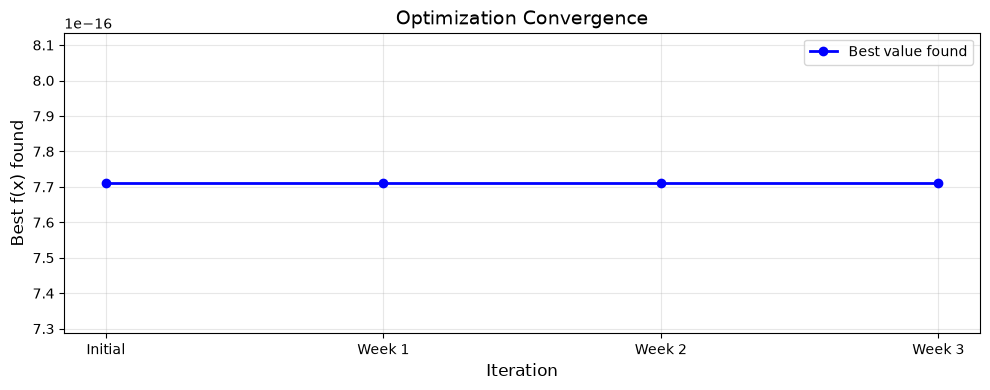

Best value found so far: 7.710875114502849e-16


In [170]:
# Track best-value-found progress across weeks
best_so_far = [
    7.710875114502849e-16,                                   # best after initial 10 points
    max(7.710875114502849e-16, -4.57919574117409e-42),       # best after Week 1
    max(7.710875114502849e-16, 1.1704238583798859e-37),      # best after Week 2
    max(7.710875114502849e-16, -5.679811964041589e-31),      # best after Week 3
]

fig, ax     = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(['Initial', 'Week 1', 'Week 2', 'Week 3'])
plt.show()

print("Best value found so far:", max(best_so_far))